In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os

In [ ]:
! pip install langchain_huggingface

In [9]:
load_dotenv()  # Load environment variables from .env file

True

In [13]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [45]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

# Logic to create an outline based on the title
def create_outline(state: BlogState) -> BlogState:
    hf_endpoint = HuggingFaceEndpoint(
        repo_id="openai/gpt-oss-120b",
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )
    title = state['title']
    prompt = f"Create a detailed outline for a blog post titled: '{title}'"
    llm = ChatHuggingFace(llm=hf_endpoint)
    outline = llm.invoke(prompt).content
    state['outline'] = outline
    return state

# Logic to create content based on the outline
def create_content(state: BlogState) -> BlogState:
    hf_endpoint = HuggingFaceEndpoint(
        repo_id="openai/gpt-oss-120b",
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )
    outline = state['outline']
    prompt = f"Write a detailed blog post based on the following outline: '{outline}'"
    llm = ChatHuggingFace(llm=hf_endpoint)
    content = llm.invoke(prompt).content
    state['content'] = content
    return state

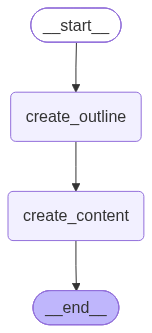

In [46]:
blog_graph = StateGraph(BlogState)

# add nodes to the graph
blog_graph.add_node("create_outline", create_outline)
blog_graph.add_node("create_content", create_content)

# add edges to the graph
blog_graph.add_edge(START, "create_outline")
blog_graph.add_edge("create_outline", "create_content")
blog_graph.add_edge("create_content", END)

blog_graph.compile()  # Visualize the graph

In [47]:
workflow = blog_graph.compile()

initial_state = BlogState(title="The Future of AI in Healthcare")
final_state = workflow.invoke(initial_state)

print(f"Detailed outline: {final_state['outline']}")
print(f"######################################################################################")
print(f"Detailed content: {final_state['content']}")

Detailed outline: **Blog Post Outline – “The Future of AI in Healthcare”**

---

### 1. Title & Meta
- **Title:** The Future of AI in Healthcare  
- **Subtitle/Tagline:** How intelligent machines are reshaping diagnosis, treatment, and patient experience  
- **Meta Description (≈155 chars):** Explore the emerging AI technologies poised to transform healthcare, the benefits they bring, the hurdles to overcome, and what the next decade may look like for patients, providers, and innovators.  

---

### 2. Hook (Opening Paragraph)
- **A vivid anecdote or statistic** – e.g., “In 2024, an AI‑driven tool flagged a rare cancer 6 months before any human radiologist could.”  
- **Why it matters now:** rapid advances in deep learning, larger biomedical datasets, and regulatory openness.  
- **Thesis statement:** AI will move from *assistive* to *strategic* roles across the entire care continuum, but its impact hinges on technology, ethics, and systemic adoption.

---

### 3. Brief Snapshot of the